# Looking at a designed peptide

Three views of one sequence from `generate/top.fasta`:

1. **Helical wheel** — the classical top-down projection, each residue at its
   angle (i x 100 degrees).
2. **Axial view** — the same helix from the side, which shows the coordinate the
   wheel discards. Two residues at the same wheel angle can be 15 angstroms
   apart along the axis; the wheel draws them on top of each other.
3. **Property profile** — hydrophobicity and charge along the chain.

The caveat that the whole submission turns on: this is an *idealised* helix.
The real molecule is a random coil in water and folds only on contact with a
membrane. The geometry drawn here is an assumption, and the ablations found it
carries no predictive signal beyond composition.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, "../src")
from amp_design.constants import EISENBERG, HYDROPHOBIC
from amp_design.features import featurize

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

HYDRO = "#d4703f"
CATION = "#4a6fa5"
ANION = "#7b4a8f"
POLAR = "#b8bcc2"
INK = "#2b2b2b"


def colour(aa):
    if aa in HYDROPHOBIC:
        return HYDRO
    if aa in "KRH":
        return CATION
    if aa in "DE":
        return ANION
    return POLAR


def read_fasta(path):
    seqs, cur = [], []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if cur:
                seqs.append("".join(cur))
                cur = []
        else:
            cur.append(line.upper())
    if cur:
        seqs.append("".join(cur))
    return seqs


top = read_fasta("../generate/top.fasta")
RANK = 1  # change this to look at any other candidate
seq = top[RANK - 1]

f = featurize(seq)
print(f"rank {RANK}: {seq}   ({len(seq)} residues)")
print(f"  net charge        {f['net_charge']:.2f}")
print(f"  hydrophobic moment {f['moment_helix']:.3f}")
print(f"  face arc width     {f['wheel_arc_width']:.0f} degrees")
print(f"  hydrophobic patches {f['h0_n_patches']:.0f}")

rank 1: NNVRGIIRLTWRVKVGGT   (18 residues)
  net charge        3.99
  hydrophobic moment 0.449
  face arc width     240 degrees
  hydrophobic patches 6


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


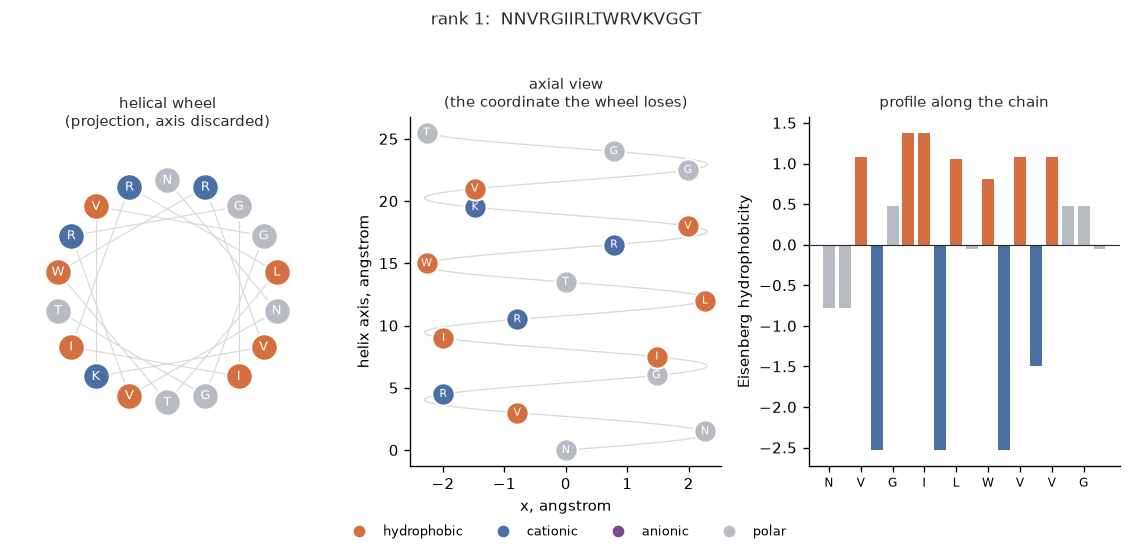

In [2]:
fig = plt.figure(figsize=(9.5, 4.2))

# --- helical wheel -------------------------------------------------------
ax = fig.add_subplot(1, 3, 1)
angles = np.deg2rad([(i * 100.0) % 360 for i in range(len(seq))])
radius = 1.0

for i, (aa, th) in enumerate(zip(seq, angles)):
    x, y = radius * np.sin(th), radius * np.cos(th)
    ax.scatter(x, y, s=260, color=colour(aa), zorder=3,
               edgecolor="white", linewidth=1.4)
    ax.text(x, y, aa, ha="center", va="center", fontsize=8,
            color="white", zorder=4, fontweight="medium")
    if i + 1 < len(seq):
        nx, ny = radius * np.sin(angles[i + 1]), radius * np.cos(angles[i + 1])
        ax.plot([x, nx], [y, ny], color="#d8d8d8", lw=0.7, zorder=1)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("helical wheel\n(projection, axis discarded)", fontsize=9, color=INK)
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)

# --- axial view ----------------------------------------------------------
ax = fig.add_subplot(1, 3, 2)
z = 1.5 * np.arange(len(seq))
x = 2.3 * np.sin(angles)

for i, aa in enumerate(seq):
    ax.scatter(x[i], z[i], s=180, color=colour(aa), zorder=3,
               edgecolor="white", linewidth=1.2)
    ax.text(x[i], z[i], aa, ha="center", va="center", fontsize=6.5,
            color="white", zorder=4)

fine = np.linspace(0, len(seq) - 1, 400)
ax.plot(2.3 * np.sin(np.deg2rad(100 * fine)), 1.5 * fine,
        color="#d8d8d8", lw=0.8, zorder=1)

ax.set_xlabel("x, angstrom")
ax.set_ylabel("helix axis, angstrom")
ax.set_title("axial view\n(the coordinate the wheel loses)", fontsize=9, color=INK)
ax.spines[["top", "right"]].set_visible(False)

# --- property profile ----------------------------------------------------
ax = fig.add_subplot(1, 3, 3)
h = np.array([EISENBERG[a] for a in seq])
pos = np.arange(len(seq))
ax.bar(pos, h, color=[colour(a) for a in seq], width=0.75)
ax.axhline(0, color=INK, lw=0.7)
ax.set_xticks(pos[::2])
ax.set_xticklabels(list(seq)[::2], fontsize=7)
ax.set_ylabel("Eisenberg hydrophobicity")
ax.set_title("profile along the chain", fontsize=9, color=INK)
ax.spines[["top", "right"]].set_visible(False)

handles = [
    plt.Line2D([], [], marker="o", ls="", color=HYDRO, label="hydrophobic"),
    plt.Line2D([], [], marker="o", ls="", color=CATION, label="cationic"),
    plt.Line2D([], [], marker="o", ls="", color=ANION, label="anionic"),
    plt.Line2D([], [], marker="o", ls="", color=POLAR, label="polar"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"rank {RANK}:  {seq}", fontsize=10, color=INK, y=1.03)
plt.tight_layout()
plt.show()

## Comparing across the factorial cells

Four peptides spanning the design's contrast axes. The interesting comparison is
between wheels that look similar and axial views that do not, which is the case
the topological descriptor was built to detect, and did not.

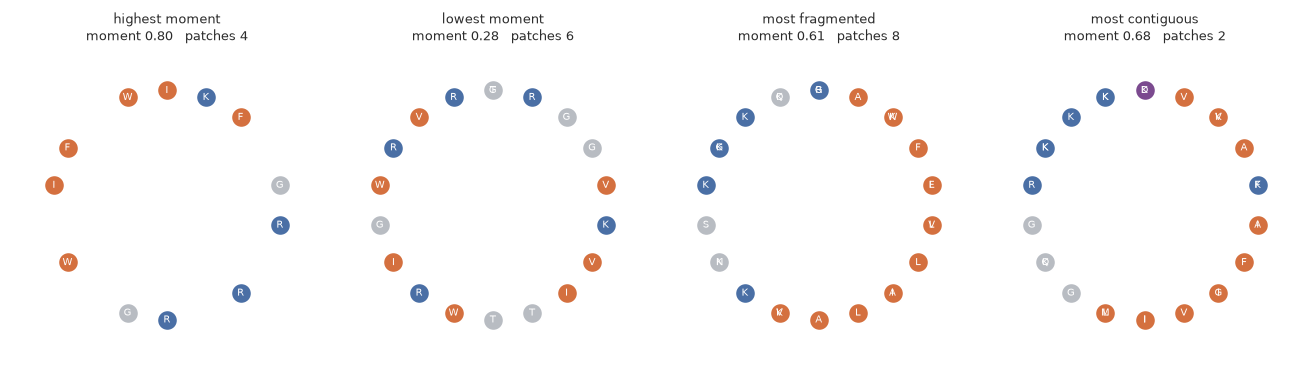

In [3]:
import pandas as pd

sub = pd.DataFrame([featurize(s) for s in top[:50]], index=top[:50])
picks = [
    sub.nlargest(1, "moment_helix").index[0],
    sub.nsmallest(1, "moment_helix").index[0],
    sub.nlargest(1, "h0_n_patches").index[0],
    sub.nsmallest(1, "h0_n_patches").index[0],
]
titles = ["highest moment", "lowest moment", "most fragmented", "most contiguous"]

fig, axes = plt.subplots(1, 4, figsize=(11, 3.0))
for ax, s, title in zip(axes, picks, titles):
    ang = np.deg2rad([(i * 100.0) % 360 for i in range(len(s))])
    for i, (aa, th) in enumerate(zip(s, ang)):
        ax.scatter(np.sin(th), np.cos(th), s=150, color=colour(aa),
                   zorder=3, edgecolor="white", linewidth=1.1)
        ax.text(np.sin(th), np.cos(th), aa, ha="center", va="center",
                fontsize=6, color="white", zorder=4)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    m = sub.loc[s]
    ax.set_title(f"{title}\nmoment {m['moment_helix']:.2f}   "
                 f"patches {m['h0_n_patches']:.0f}", fontsize=8, color=INK)

plt.tight_layout()
plt.show()

In [4]:
import py3Dmol, PeptideBuilder
from PeptideBuilder import Geometry
from Bio.PDB import PDBIO
import io

seq = top[0]

# idealised alpha-helix: phi -57, psi -47
structure = PeptideBuilder.initialize_res(Geometry.geometry(seq[0]))
for aa in seq[1:]:
    g = Geometry.geometry(aa)
    g.phi, g.psi_im1 = -57, -47
    PeptideBuilder.add_residue(structure, g)

out = io.StringIO()
io_pdb = PDBIO(); io_pdb.set_structure(structure); io_pdb.save(out)

view = py3Dmol.view(width=700, height=500)
view.addModel(out.getvalue(), "pdb")
view.setStyle({"stick": {"radius": 0.15}, "sphere": {"scale": 0.25}})
view.setBackgroundColor("white")
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
import requests
pdb = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=seq).text

In [6]:
r = requests.post("https://api.esmatlas.com/foldSequence/v1/pdb/", data=seq)
print(r.status_code, len(r.text))
print(r.text[:300])

200 13083
HEADER                                            18-OCT-22                     
TITLE     ESMFOLD V1 PREDICTION FOR INPUT
REMARK   1                                                                      
REMARK   1 REFERENCE 1                                                          
REMARK   1  AUT


In [10]:
view = py3Dmol.view(width=700, height=500)
view.addModel(r.text, "pdb")
view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
view.setBackgroundColor("white")
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
plddt = [float(l[60:66]) for l in r.text.splitlines() if l.startswith("ATOM") and l[12:16].strip() == "CA"]
print(f"mean pLDDT {sum(plddt)/len(plddt):.1f}")

mean pLDDT 0.7
